# Generate k curve for $N = 2 ^{25}$ and $\alpha = 0.62$, then generate a bunch of tables 

## Imports 

In [2]:
from utils import *
from math import e, log
import pickle
import matplotlib.pyplot as plt
import csv
import numpy as np
import pandas as pd

## Constants

In [3]:
N = 2 ** 25
p = 1-e**-2 # our table coverage
cost_factor = 5
alpha = 0.62  # maximality factor
t = round(log(1-p)/log(1-N**(-1/3)))

## Optimise and store in pickle file

In [40]:
def alt_optimise_kj(N, p, alpha, factor, lower_bound, t=-1, maxiter=5000000):   # add v_cost if want vanilla cost to be set beforehand

    if t == -1:
        t = round(log(1-p)/log(1-N**(-1/3))) # Calculate t

    mt_max = (2*N)/(t+2)
    mt_target = alpha * mt_max
    if alpha == 1:
        m_0 = N
    else:
        m_0 = round(mt_target/(1-alpha))    # our starting m_0

    
    ## set the bound and target function
    bound = Bounds([lower_bound for i in range(t)], [float('inf') for i in range(t)])
    
    # our target function that needs to be > 0
    # instead of using the target function, we can use the cost function as the objective function
    # need to get the cost of a vanilla rainbow table with the same parameters
    
    # Const * P(vanilla) - P(cherry) > 0
    v_cost, m = vanilla_cost(N, m_0, t)
    v_cost = v_cost * factor
    ineq_cons = {'type': 'ineq', 'fun' : lambda x: v_cost - cost(x, N, m_0)[0]}

    ## use 1 as starting values for cherry-picking
    starting_values = [1 for i in range(t)]
    

    ## call the optimizer
    # maximise the 
    # 5000000 normally
    res = minimize(lambda Kj: m_t(Kj, N, m_0), starting_values, bounds=bound, constraints=ineq_cons,method = "SLSQP", options={'disp': True, "maxiter": maxiter, "eps": 200, "ftol": 1})
    
    ## res.x is the result of the optimization
    final_cost, m_values = cost(res.x, N, m_0) # calculate the final cost and m values
    return res.x, m_0, final_cost, m_values

In [41]:
results = alt_optimise_kj(N, p, alpha, cost_factor, 1, maxiter=1000)
kjs, m_0, final_cost, m_values = results

## store in a pickle file in data folder
with open("data/cherry_N_25_alpha_0.62_cost_5_optimisation_results.pkl", "wb") as f:
    pickle.dump(results, f)

Optimization terminated successfully    (Exit mode 0)
            Current function value: -77578.96643980671
            Iterations: 15
            Function evaluations: 9683
            Gradient evaluations: 15


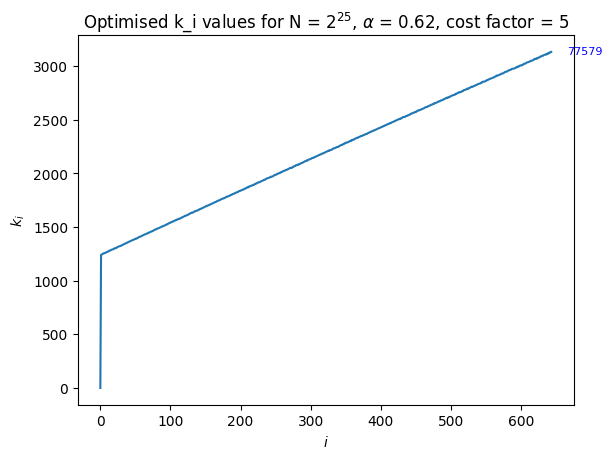

In [42]:
## plot k curve for this alpha
plt.plot(kjs)
plt.xlabel('$i$')
plt.ylabel('$k_i$')

# label mt at the end of the plot, not an arrow, just text
mt = m_values[-1]
y = kjs[-1]

plt.annotate(round(mt),
             xy = (len(kjs)+9, y),   # place text outside box in line with end of curve
             xytext = (6, 0),
             color = 'blue',
             textcoords = 'offset points',
             size=8,
             va='center')


plt.title(r'Optimised k_i values for N = $2^{25}$, $\alpha$ = 0.62, cost factor = 5')
plt.show()

## Build 20 tables and get average $m_t$

In [ ]:
%%script false

# build the actual table - 20 times
samples = 20
generation_results = []
generation_mt = []
generation_costs = []

##############################################################

# first generate starpoints and store them
mt_max = (2*N)/(t+2)
mt_target = alpha * mt_max
cherry_m_0 = round(mt_target/(1-alpha))    # our starting m_0
this_alpha_startpoints = []
# generate sample sets of starpoints
for i in range(samples):
    starpoints = set()
    while len(starpoints) < (cherry_m_0):
        starpoints.add(random.randint(0, N-1))

    this_alpha_startpoints.append(starpoints)

##############################################################

# build the cherry table sample times and store it for later
this_alpha_tables = []
this_alpha_mt = []
this_alpha_costs = []

# get the optimisation kis for this alpha
optimisation_kis_for_alpha = kjs

# build sample tables
for i in range(samples):
    # get starpoints
    starpoints = this_alpha_startpoints[i]
    # make the table with these startpoints
    table, rf_indexes, hashes, reductions, duration = build_cherry_table(N, t, starpoints, optimisation_kis_for_alpha)
    # append to this alpha's tables
    this_alpha_tables.append((table, rf_indexes))
    this_alpha_mt.append(len(table))
    this_alpha_costs.append(hashes + (reductions * 1/577.44))  # total cost is hashes + reductions * 1/577.44

# append to main list
generation_results.append(this_alpha_tables)
generation_mt.append(this_alpha_mt)
generation_costs.append(this_alpha_costs)

##############################################################

# store in a csv file
with open("data/cherry_N_20_alpha_0.62_cost_5_with_cost_results.csv", "w", newline='') as f:
    f_alpha = csv.writer(f) # create a csv writer

    # create a list of headers for the different trials
    trial_headers = []
    cost_headers = []
    for i in range(samples):
        trial_headers.append(f"trial_{i+1}")
        cost_headers.append(f"cost_{i+1}")
    
    f_alpha.writerow(["alpha", "optimiser_mt"] + trial_headers  + ["optimiser_cost"] + cost_headers)

    # add in data for each alpha
    row = [alpha, m_values[-1] + generation_mt[0] + final_cost + generation_costs[0]]
    f_alpha.writerow(row)

In [24]:
## read csv
df = pd.read_csv("data/cherry_N_20_tables.csv")

## find mean of mt column
mean_mt = df['mt'].mean()
print(mean_mt)

# find mean of vanilla table 
mt_max = (2*N)/(t + 2)

expected_mt = round(alpha * mt_max)
print(expected_mt)

8587.7
6374
